# 🎬 Conditional Latent Residual Rank Analysis
### Full pipeline — Google Colab (GPU recommended)

**Stages:**
1. Install dependencies
2. Clone / upload source files
3. Configure parameters
4. Extract VAE latents from video
5. Build Raw / Diff / Conditional-Residual populations
6. Spectral analysis (SVD, Effective Rank, Scree Plot)
7. UMAP 2-D visualisation
8. Evaluate predictor (SSIM / PSNR / FID)
9. Browse output artefacts

In [1]:
import subprocess
result = subprocess.run(
    ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
    capture_output=True, text=True
)
if result.returncode == 0:
    print("✅ GPU detected:", result.stdout.strip())
else:
    print("⚠️  No GPU found. Go to Runtime → Change runtime type → T4 GPU.")

✅ GPU detected: Tesla T4, 15360 MiB


## 1 · Install Dependencies

In [2]:
%pip install -q \
    torch torchvision \
    diffusers transformers accelerate \
    opencv-python-headless \
    scikit-learn scikit-image \
    scipy \
    umap-learn \
    matplotlib tqdm Pillow

print("✅ All packages installed.")

✅ All packages installed.


## 2 · Clone or Upload Source Files

**Option A (recommended):** clone from GitHub — edit `REPO_URL` to point at your fork.  
**Option B:** upload the `.py` files manually — uncomment the block in the next cell.

In [3]:
import os, sys, subprocess

REPO_URL = "https://github.com/abhiram100/video_compression.git"
REPO_DIR = "video_compression"

def run(cmd):
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.stdout: print(result.stdout.strip())
    if result.stderr: print(result.stderr.strip())
    return result.returncode

if not os.path.isdir(REPO_DIR):
    print(f"Cloning {REPO_URL} …")
    rc = run(f"git clone {REPO_URL} {REPO_DIR}")
    if rc != 0:
        raise RuntimeError(
            f"git clone failed (exit {rc}).\n"
            "Possible causes:\n"
            "  • The repo is private — authenticate first:\n"
            "      !git clone https://<token>@github.com/abhiram100/video_compression.git\n"
            "  • The repo doesn't exist yet — push it from your local machine first.\n"
            "  • No internet in this runtime — try Runtime → Disconnect and reconnect."
        )
else:
    print(f"Repo already cloned, pulling latest …")
    run(f"git -C {REPO_DIR} pull")

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

py_files = [f for f in os.listdir(REPO_DIR) if f.endswith(".py")]
print(f"\n✅ Ready — {len(py_files)} .py files found:", py_files)


Repo already cloned, pulling latest …
Updating e3ee5fb..a83b93c
Fast-forward
 colab_pipeline.ipynb  | 294 +++++++++++++++++++++++++++++++++++++++++++-------
 evaluate_predictor.py |  85 +++++++++++----
 2 files changed, 318 insertions(+), 61 deletions(-)
From https://github.com/abhiram100/video_compression
   e3ee5fb..a83b93c  main       -> origin/main

✅ Ready — 6 .py files found: ['visualize_umap.py', 'run_all.py', 'spectral_analysis.py', 'build_populations.py', 'extract_latents.py', 'evaluate_predictor.py']
Updating e3ee5fb..a83b93c
Fast-forward
 colab_pipeline.ipynb  | 294 +++++++++++++++++++++++++++++++++++++++++++-------
 evaluate_predictor.py |  85 +++++++++++----
 2 files changed, 318 insertions(+), 61 deletions(-)
From https://github.com/abhiram100/video_compression
   e3ee5fb..a83b93c  main       -> origin/main

✅ Ready — 6 .py files found: ['visualize_umap.py', 'run_all.py', 'spectral_analysis.py', 'build_populations.py', 'extract_latents.py', 'evaluate_predictor.py']


## 3 · Configure Pipeline Parameters

Edit the variables below — every subsequent cell reads from here.

In [4]:
# ── Video source ──────────────────────────────────────────────────────────────
# Option A: path to a video already on Colab / mounted Drive
# VIDEO_PATH = "/content/my_video.mp4"   # ← change this

# Option B: download a sample clip (uncomment to use)
!wget -q -O /content/sample.mp4 "https://test-videos.co.uk/vids/bigbuckbunny/mp4/h264/360/Big_Buck_Bunny_360_10s_1MB.mp4"
VIDEO_PATH = "/content/sample.mp4"

# ── Output directory ──────────────────────────────────────────────────────────
OUTPUT_DIR = "/content/results"

# ── Extraction ────────────────────────────────────────────────────────────────
N_FRAMES    = 30           # total frames to extract
VAE_MODEL   = "stabilityai/sd-vae-ft-mse"
FRAME_SIZE  = 512          # resize each frame to this square before encoding
SAMPLING    = "dense"      # "uniform" (spread across video) | "dense" (first N frames)

# ── Population building ───────────────────────────────────────────────────────
RIDGE_ALPHA = 1.0          # Ridge regularisation strength
PCA_DIMS    = 256          # PCA dims before fitting Ridge

# ── Spectral analysis ─────────────────────────────────────────────────────────
N_SVD_COMPONENTS = None    # None → min(T, D)-1  (recommended)

# ── UMAP ─────────────────────────────────────────────────────────────────────
UMAP_MAX_POINTS = 2000     # points per population (subsampled for speed)

# ── Evaluation ────────────────────────────────────────────────────────────────
N_VIZ        = 20          # side-by-side comparison panels to save
LATENT_SHAPE = "4,64,64"  # C,H,W — (4,64,64) for SD VAE @ 512 px input
COMPUTE_FID  = True        # set False to skip FID and save ~1 min
DECODE_BATCH = 2           # frames decoded per VAE forward pass.
                           # Decoded frames are streamed to disk (memmap), so
                           # RAM never accumulates. Set to 1 if still OOM.

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("✅ Config OK — output directory:", OUTPUT_DIR)


✅ Config OK — output directory: /content/results


## 4 · Step 1 — Extract VAE Latents

Encodes each sampled frame through the SD VAE encoder and saves `latents.npy` — shape `(T, C×H×W)`.

In [5]:
from extract_latents import extract_latents

latents_path = extract_latents(
    video_path=VIDEO_PATH,
    n_frames=N_FRAMES,
    model_id=VAE_MODEL,
    output_dir=OUTPUT_DIR,
    frame_size=FRAME_SIZE,
    sampling=SAMPLING,
)
print("\n✅ Latents saved to:", latents_path)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


[extract] device=cuda  model=stabilityai/sd-vae-ft-mse  sampling=dense


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


[extract] video frames=300  extracting 30 frames (consecutive)


Encoding frames: 100%|██████████| 30/30 [00:08<00:00,  3.50it/s]

[extract] saved (30, 16384) → /content/results/latents.npy

✅ Latents saved to: /content/results/latents.npy


## 5 · Step 2 — Build Populations

Generates three matrices and fits + saves the Ridge predictor:
- `raw.npy` — raw latents
- `diff.npy` — linear temporal difference `z_t − z_{t−1}`
- `cond.npy` — conditional residual `z_t − Ridge(PCA(z_{t−1}))`
- `predictor.pkl` — fitted SVD + Ridge (reused in Step 5)

In [6]:
from build_populations import build_populations

paths = build_populations(
    latents_path=latents_path,
    output_dir=OUTPUT_DIR,
    ridge_alpha=RIDGE_ALPHA,
    pca_dims=PCA_DIMS,
)
print("\n✅ Population files:", {k: os.path.basename(v) for k, v in paths.items()})

[build_populations] loaded latents (30, 16384)
[build_populations] raw    (30, 16384) → /content/results/raw.npy
[build_populations] diff   (29, 16384) → /content/results/diff.npy
[build_populations] fitting PCA(28) for Ridge predictor …
[build_populations] fitting Ridge(alpha=1.0) …
[build_populations] cond   (29, 16384) → /content/results/cond.npy
[build_populations] predictor → /content/results/predictor.pkl

✅ Population files: {'raw': 'raw.npy', 'diff': 'diff.npy', 'cond': 'cond.npy', 'predictor': 'predictor.pkl'}
[build_populations] fitting Ridge(alpha=1.0) …
[build_populations] cond   (29, 16384) → /content/results/cond.npy
[build_populations] predictor → /content/results/predictor.pkl

✅ Population files: {'raw': 'raw.npy', 'diff': 'diff.npy', 'cond': 'cond.npy', 'predictor': 'predictor.pkl'}


## 6 · Step 3 — Spectral Analysis

SVD → normalised eigenvalues → Participation Ratio (Effective Rank) → cumulative variance table.

[spectral] analysing 'raw'  shape=(30, 16384) …
  PR=2.9   dims@95%=12   dims@99%=23
[spectral] analysing 'diff'  shape=(29, 16384) …
  PR=24.4   dims@95%=25   dims@99%=27
[spectral] analysing 'cond'  shape=(29, 16384) …
  PR=2.9   dims@95%=12   dims@99%=23
[spectral] analysing 'diff'  shape=(29, 16384) …
  PR=24.4   dims@95%=25   dims@99%=27
[spectral] analysing 'cond'  shape=(29, 16384) …
  PR=1.0   dims@95%=1   dims@99%=1
  PR=1.0   dims@95%=1   dims@99%=1
[spectral] scree plot saved → /content/results/scree_plot.png
-------------------------------------------------------------------------------------
Metric                            Raw Latents  Linear Residual   Conditional Residual
-------------------------------------------------------------------------------------
Effective Rank (PR)                      2.9            24.4                   1.0
Dims for 95% Var                          12              25                     1
Dims for 99% Var                          23      

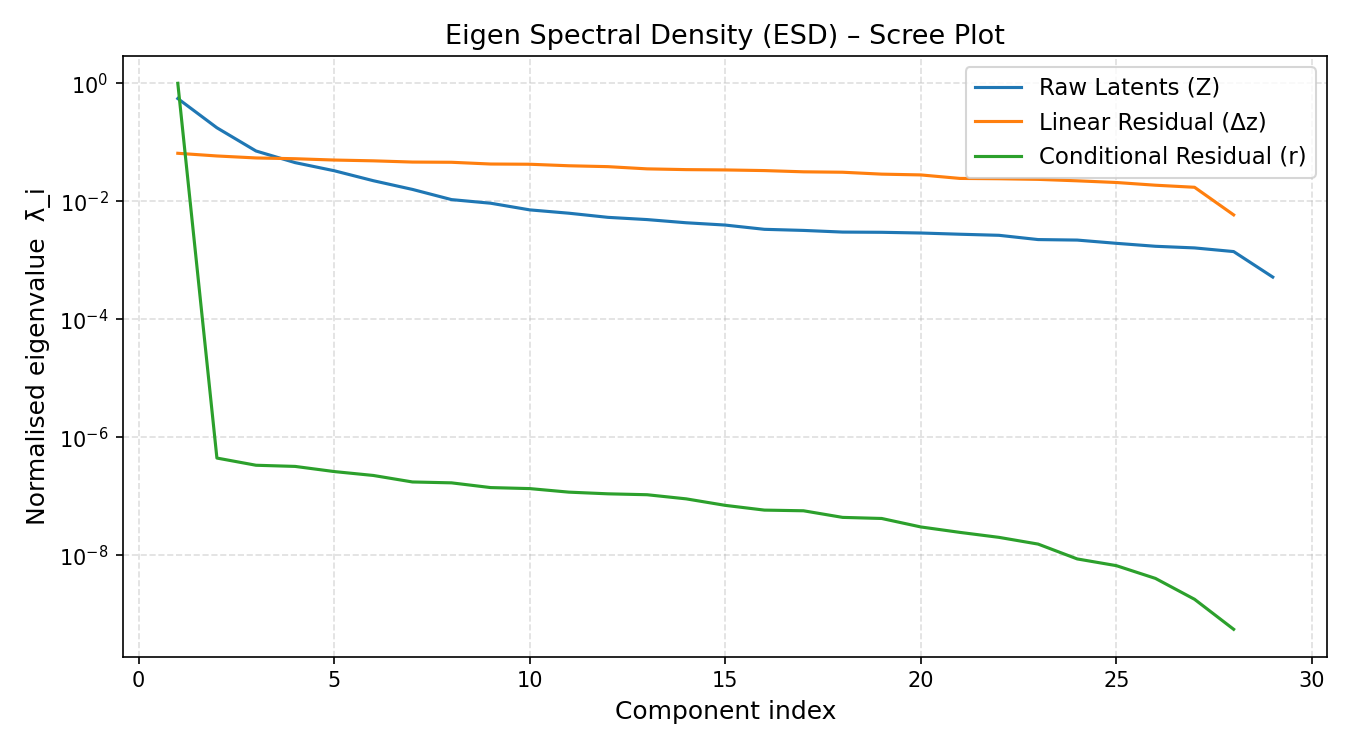

In [7]:
from spectral_analysis import run_spectral_analysis
from IPython.display import Image as IPImage, display

results = run_spectral_analysis(
    data_dir=OUTPUT_DIR,
    output_dir=OUTPUT_DIR,
    n_components=N_SVD_COMPONENTS,
)

display(IPImage(os.path.join(OUTPUT_DIR, "scree_plot.png")))

In [8]:
with open(os.path.join(OUTPUT_DIR, "rank_table.txt")) as f:
    print(f.read())

-------------------------------------------------------------------------------------
Metric                            Raw Latents  Linear Residual   Conditional Residual
-------------------------------------------------------------------------------------
Effective Rank (PR)                      2.9            24.4                   1.0
Dims for 95% Var                          12              25                     1
Dims for 99% Var                          23              27                     1
-------------------------------------------------------------------------------------

Conclusion:
✅  HYPOTHESIS CONFIRMED:  PR_cond (1.0) < PR_raw (2.9)



## 7 · Step 4 — UMAP Visualisation

Projects raw latents and conditional residuals into 2-D.  
Colour + size + opacity all encode temporal progression (early = faint/small → late = bright/large).

[umap] raw_sub=(29, 16384)  cond_sub=(29, 16384)
[umap] PCA pre-reduction to 50 dims …
[umap] fitting UMAP (n_neighbors=15, min_dist=0.1) …
[umap] fitting UMAP (n_neighbors=15, min_dist=0.1) …
[umap] scatter plot saved → /content/results/umap_scatter.png
[umap] scatter plot saved → /content/results/umap_scatter.png


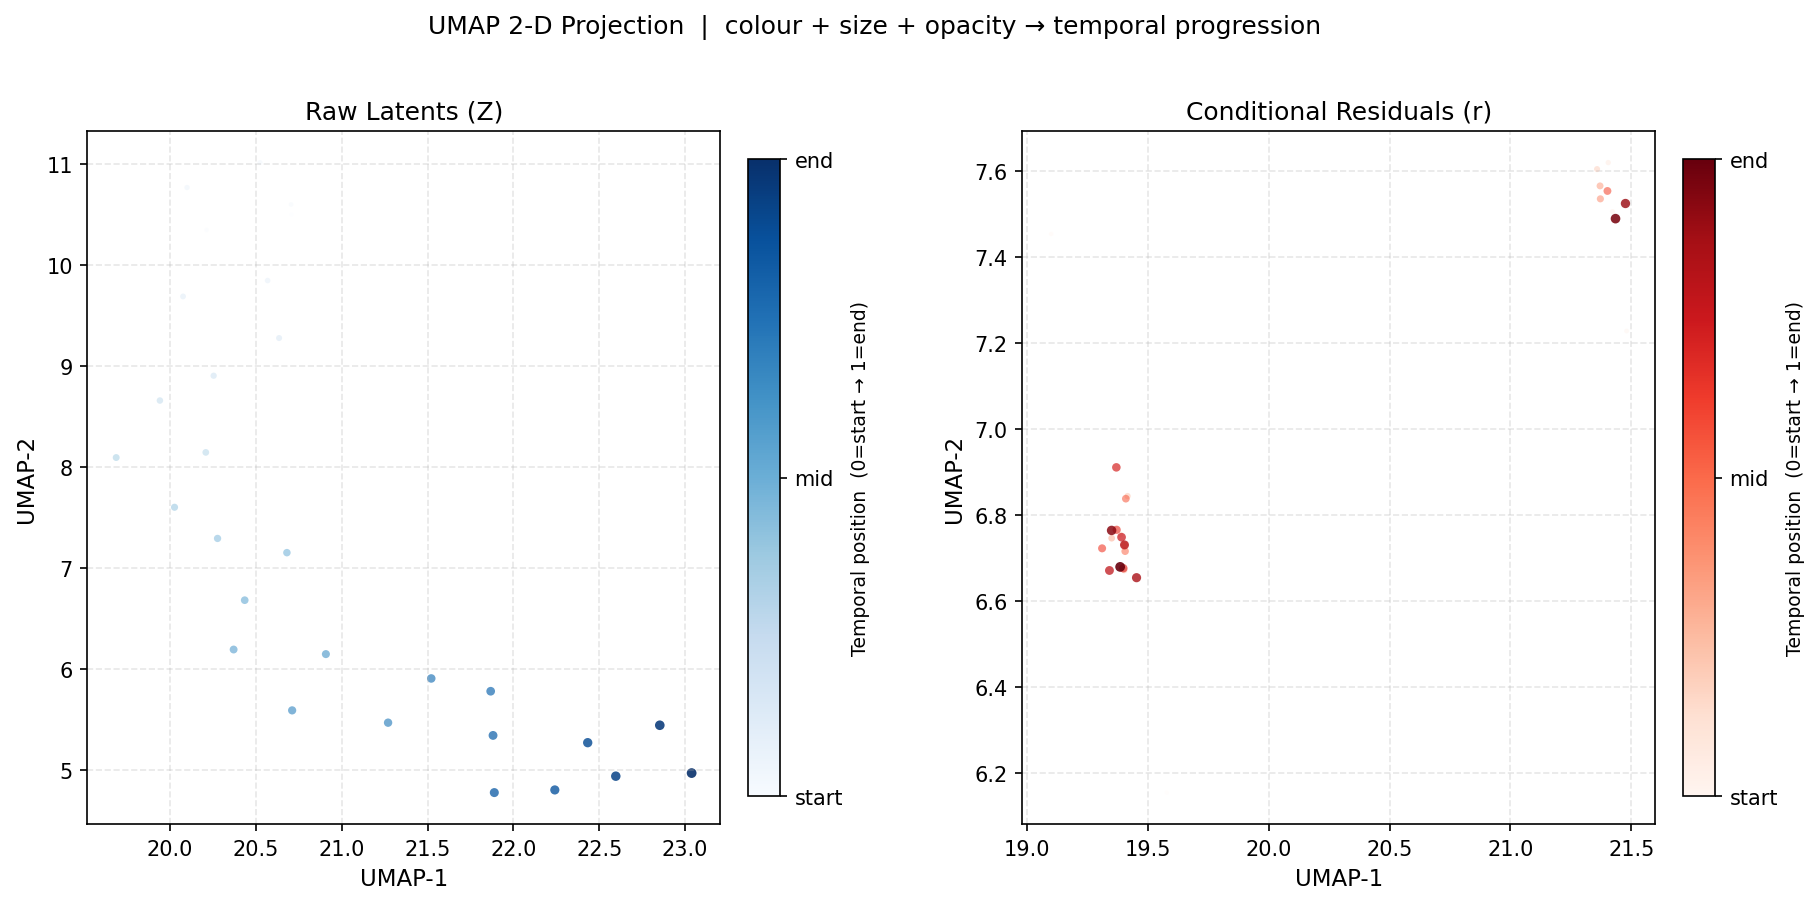

In [9]:
from visualize_umap import run_umap

run_umap(
    data_dir=OUTPUT_DIR,
    output_dir=OUTPUT_DIR,
    max_points=UMAP_MAX_POINTS,
)

display(IPImage(os.path.join(OUTPUT_DIR, "umap_scatter.png")))

## 8 · Step 5 — Evaluate Predictor (SSIM / PSNR / FID)

For every consecutive frame pair:
1. Predict `ẑ_t = Ridge(PCA(z_{t−1}))`
2. Decode both `z_t` (ground truth) and `ẑ_t` (prediction) via VAE
3. Compute per-frame SSIM & PSNR
4. Compute FID via Inception-v3 pool3 features
5. Save side-by-side panels: **Previous | Ground Truth | Predicted**

In [10]:
from evaluate_predictor import run_evaluation

C, H, W = map(int, LATENT_SHAPE.split(","))

metrics = run_evaluation(
    data_dir=OUTPUT_DIR,
    output_dir=OUTPUT_DIR,
    model_id=VAE_MODEL,
    latent_shape=(C, H, W),
    n_viz=N_VIZ,
    decode_batch=DECODE_BATCH,
    compute_fid_flag=COMPUTE_FID,
)

[eval] loaded latents (30, 16384)
[eval] running Ridge predictor …
[eval] loading VAE (stabilityai/sd-vae-ft-mse) on cuda …
[eval] decoding ground-truth frames …
[eval] decoding ground-truth frames …


GT decode: 100%|██████████| 14/14 [00:14<00:00,  1.06s/batch]



[eval] decoding predicted frames …


Pred decode: 100%|██████████| 14/14 [00:15<00:00,  1.10s/batch]



[eval] decoding previous frames (for panel context) …


...

[eval] computing FID …
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 198MB/s] 



[eval] FID = 0.14
[eval] saving 20 comparison panels …


Panels: 100%|██████████| 20/20 [00:08<00:00,  2.22it/s]


  Conditional Predictor Evaluation
  Frames evaluated : 29
  SSIM  mean ± std : 0.9995 ± 0.0017
  SSIM  median     : 1.0000
  SSIM  min / max  : 0.9921 / 1.0000

  PSNR  mean ± std : 62.79 ± 7.94 dB
  PSNR  median     : 64.08 dB
  PSNR  min / max  : 38.08 / 74.47 dB

  FID              : 0.14
[eval] metrics saved → /content/results/eval_metrics.txt
[eval] panels saved  → /content/results/eval_frames/


In [11]:
with open(os.path.join(OUTPUT_DIR, "eval_metrics.txt")) as f:
    print(f.read())

  Conditional Predictor Evaluation
  Frames evaluated : 29
  SSIM  mean ± std : 0.9995 ± 0.0017
  SSIM  median     : 1.0000
  SSIM  min / max  : 0.9921 / 1.0000

  PSNR  mean ± std : 62.79 ± 7.94 dB
  PSNR  median     : 64.08 dB
  PSNR  min / max  : 38.08 / 74.47 dB

  FID              : 0.14



## 9 · Browse Output Artefacts

In [12]:
print("── Output files ──────────────────────────────────────")
for root, dirs, files in os.walk(OUTPUT_DIR):
    dirs.sort(); files.sort()
    level = root.replace(OUTPUT_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for fname in files:
        fpath = os.path.join(root, fname)
        size_kb = os.path.getsize(fpath) / 1024
        print(f"{indent}  {fname}  ({size_kb:.0f} KB)")

── Output files ──────────────────────────────────────
results/
  _imgs_gt.npy  (22272 KB)
  _imgs_pred.npy  (22272 KB)
  _imgs_prev.npy  (22272 KB)
  cond.npy  (1856 KB)
  diff.npy  (1856 KB)
  eval_metrics.txt  (0 KB)
  latents.npy  (1920 KB)
  predictor.pkl  (3649 KB)
  rank_table.txt  (1 KB)
  raw.npy  (1920 KB)
  scree_plot.png  (83 KB)
  umap_scatter.png  (88 KB)
  eval_frames/
    frame_0000.png  (587 KB)
    frame_0001.png  (702 KB)
    frame_0002.png  (658 KB)
    frame_0004.png  (592 KB)
    frame_0005.png  (561 KB)
    frame_0007.png  (536 KB)
    frame_0008.png  (566 KB)
    frame_0010.png  (541 KB)
    frame_0011.png  (563 KB)
    frame_0013.png  (514 KB)
    frame_0014.png  (579 KB)
    frame_0016.png  (580 KB)
    frame_0017.png  (548 KB)
    frame_0019.png  (539 KB)
    frame_0020.png  (569 KB)
    frame_0022.png  (546 KB)
    frame_0023.png  (532 KB)
    frame_0025.png  (592 KB)
    frame_0026.png  (590 KB)
    frame_0028.png  (525 KB)


In [13]:
import glob, math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

panels = sorted(glob.glob(os.path.join(OUTPUT_DIR, "eval_frames", "*.png")))
n_show = min(6, len(panels))

if n_show == 0:
    print("No panels found — check Step 5 completed successfully.")
else:
    pick = [int(i) for i in np.linspace(0, len(panels) - 1, n_show)]
    fig, axes = plt.subplots(n_show, 1, figsize=(14, 5 * n_show))
    if n_show == 1:
        axes = [axes]
    for ax, idx in zip(axes, pick):
        ax.imshow(mpimg.imread(panels[idx]))
        ax.set_title(os.path.basename(panels[idx]), fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [14]:
# Optional: download all results as a zip
# import shutil
# from google.colab import files
# shutil.make_archive("/content/results_export", "zip", OUTPUT_DIR)
# files.download("/content/results_export.zip")